In [132]:
import geopandas as gpd
import fiona

# Path to swissTLM3D, swissBOUNDARIES3D and Corine Land Cover
tlm_path = "C:/ZHAW/5.Semester/PA2/data/SWISSTLM3D_2025.gpkg"
boundaries_path = "C:/ZHAW/5.Semester/PA2/data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
clc_path = "C:/ZHAW/5.Semester/PA2/data/Results/U2018_CLC2018_V2020_20u1.gpkg"


# List all layers
layers = fiona.listlayers(tlm_path)
print(f"tlm layers: {layers}")  
layers = fiona.listlayers(boundaries_path)
print(f"boundary layers: {layers}") 
layers = fiona.listlayers(clc_path)
print(f"clc layers: {layers}")


tlm layers: ['tlm_strassen_aus_einfahrt', 'tlm_bb_bodenbedeckung', 'tlm_bb_einzelbaum_gebuesch', 'tlm_eo_einzelobjekt', 'tlm_oev_eisenbahn', 'tlm_gewaesser_fliessgewaesser', 'tlm_namen_flurname', 'tlm_areale_freizeitareal', 'tlm_bauten_gebaeude_footprint', 'tlm_namen_gebietsname', 'tlm_name_gelaendename', 'tlm_oev_haltestelle', 'tlm_bauten_leitung', 'tlm_bauten_mauer', 'tlm_namen_name_pkt', 'tlm_areale_nutzungsareal', 'tlm_oev_schifffahrt', 'tlm_areale_schutzgebiet', 'tlm_namen_siedlungsname', 'tlm_bauten_sportbaute_lin', 'tlm_bauten_sportbaute_ply', 'tlm_bauten_staubaute', 'tlm_gewaesser_stehendes_gewaesser', 'tlm_strassen_strasse', 'tlm_strassen_strasseninfo', 'tlm_oev_uebrige_bahn', 'tlm_bauten_verbauung', 'tlm_areale_verkehrsareal', 'tlm_bauten_verkehrsbaute_lin', 'tlm_bauten_verkehrsbaute_ply', 'tlm_bauten_versorgungsbaute_pkt', 'tlm_bb_glamos', 'tlm_bauten_leitung_stromtrasse', 'tlm_areale_nutzungsareal_schule', 'tlm_areale_schule', 'tlm_strassen_strassenname', 'tlm_strassen_stra

In [133]:
landcover_sh_clc = gpd.read_file(clc_path, layer="U2018_CLC2018_V2020_20u1")

 
print(landcover_sh_clc.columns)



Index(['OBJECTID', 'Code_18', 'Remark', 'Area_Ha', 'Shape_Length',
       'Shape_Area', 'geometry'],
      dtype='object')


In [134]:
print(landcover_sh_clc["Code_18"])

0      112
1      112
2      112
3      112
4      112
      ... 
188    313
189    313
190    313
191    512
192    511
Name: Code_18, Length: 193, dtype: object


In [135]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 1. Die CLC_legend.csv-Datei laden
clc_legend = pd.read_csv("C:/ZHAW/5.Semester/PA2/data/Results/Info/Legend/Vector/CLC_legend.csv", sep=';')

# # 2. Den "CLC_CODE" als Index festlegen, um eine Nachschlagetabelle zu erstellen
# clc_legend_indexed = clc_legend.set_index("CLC_CODE")

# Überprüfen Sie die vorbereitete Tabelle
print("Vorbereitete Nachschlagetabelle:")
print(clc_legend.head())

Vorbereitete Nachschlagetabelle:
   GRID_CODE  CLC_CODE                                      LABEL3  \
0          1       111                     Continuous urban fabric   
1          2       112                  Discontinuous urban fabric   
2          3       121              Industrial or commercial units   
3          4       122  Road and rail networks and associated land   
4          5       123                                  Port areas   

           RGB  
0  230-000-077  
1  255-000-000  
2  204-077-242  
3  204-000-000  
4  230-204-204  


In [136]:
print(landcover_sh_clc.head())

   OBJECTID Code_18 Remark     Area_Ha  Shape_Length    Shape_Area  \
0   1017625     112   None   80.820126   7055.077298  8.082013e+05   
1   1017783     112   None  161.691835  10461.377355  1.616918e+06   
2   1017791     112   None    0.146694    271.229232  1.466945e+03   
3   1017795     112   None  161.120051  10432.388571  1.611201e+06   
4   1017799     112   None   27.522222   3144.386954  2.752222e+05   

                                            geometry  
0  MULTIPOLYGON (((8.57405 47.57627, 8.57286 47.5...  
1  MULTIPOLYGON (((8.86286 47.65489, 8.85973 47.6...  
2  MULTIPOLYGON (((8.43461 47.65998, 8.43366 47.6...  
3  MULTIPOLYGON (((8.87462 47.6598, 8.87446 47.65...  
4  MULTIPOLYGON (((8.49465 47.66356, 8.49619 47.6...  


In [137]:
import pandas as pd
import geopandas as gpd

# ANNAHME: Ihr GeoDataFrame und Ihre CSV-Datei sind bereits geladen.
# landcover_sh_clc = gpd.read_file("path/to/your/file.shp")
# clc_legend = pd.read_csv("CLC_legend.csv")

# 1. Datentypen in der clc_legend-Tabelle korrigieren
#    (Dieser Schritt funktioniert bereits, aber ich füge ihn zur Vollständigkeit hinzu)
clc_legend['CLC_CODE'] = clc_legend['CLC_CODE'].astype(int)

# 2. Datentypen in der landcover_sh_clc GeoDataFrame korrigieren
#    Wir konvertieren die Spalte in einen Integer, damit sie zur Legende passt.
landcover_sh_clc['Code_18'] = landcover_sh_clc['Code_18'].astype(int)

# 3. Den Index für die Nachschlagetabelle setzen
clc_legend_indexed = clc_legend.set_index('CLC_CODE')

# 4. Die Spalten "LABEL3" und "RGB" der GeoDataFrame zuweisen
landcover_sh_clc['landcover'] = landcover_sh_clc['Code_18'].map(clc_legend_indexed['LABEL3'])
landcover_sh_clc['RGB'] = landcover_sh_clc['Code_18'].map(clc_legend_indexed['RGB'])

# Überprüfen Sie die GeoDataFrame mit den neuen Spalten
print("\nGeoDataFrame mit neuen Spalten:")
print(landcover_sh_clc[['Code_18', 'landcover', 'RGB']].head())


GeoDataFrame mit neuen Spalten:
   Code_18                   landcover          RGB
0      112  Discontinuous urban fabric  255-000-000
1      112  Discontinuous urban fabric  255-000-000
2      112  Discontinuous urban fabric  255-000-000
3      112  Discontinuous urban fabric  255-000-000
4      112  Discontinuous urban fabric  255-000-000


In [138]:
import numpy as np

print(np.unique(landcover_sh_clc["landcover"]))

['Broad-leaved forest' 'Complex cultivation patterns' 'Coniferous forest'
 'Discontinuous urban fabric' 'Industrial or commercial units'
 'Land principally occupied by agriculture, with significant areas of natural vegetation'
 'Mineral extraction sites' 'Mixed forest' 'Non-irrigated arable land'
 'Pastures' 'Road and rail networks and associated land' 'Vineyards'
 'Water bodies' 'Water courses']


In [139]:
# 1. Kantonsschichten laden
cantons = gpd.read_file(boundaries_path, layer="tlm_kantonsgebiet")

print(cantons.columns)


Index(['uuid', 'datum_aenderung', 'datum_erstellung', 'erstellung_jahr',
       'erstellung_monat', 'grund_aenderung', 'herkunft', 'herkunft_jahr',
       'herkunft_monat', 'revision_jahr', 'revision_monat',
       'revision_qualitaet', 'objektart', 'kantonsnummer', 'see_flaeche',
       'kantonsflaeche', 'name', 'icc', 'einwohnerzahl', 'geometry'],
      dtype='object')


In [140]:
# 2. Schaffhausen auswählen
sh = cantons[cantons["name"] == "Schaffhausen"]

In [141]:
# 3. Beispiel: Landcover aus swissTLM3D laden
landcover = gpd.read_file(tlm_path, layer="tlm_bb_bodenbedeckung")

In [142]:
print(len(landcover))

842825


In [143]:
# 4. Clip: nur Objekte innerhalb der Kantonsgrenze
landcover_sh = gpd.clip(landcover, sh)

print(len(landcover_sh))
print(landcover_sh.head())

2876
                                          uuid datum_aenderung  \
343898  {11B998BC-C1E3-4BA9-83C9-50EA3F27C32A}      2019-12-11   
760012  {E37F6B10-F29F-4E67-90ED-D59024BA1BE4}      2019-12-11   
347267  {1744BDE7-2E11-46A5-99CF-876035538503}      2020-01-08   
241816  {A3C86332-5092-47B0-8D3E-42D58817E01A}      2019-12-11   
241817  {C3256931-8C77-467A-A89F-0EB8C37145C9}      2020-01-08   

       datum_erstellung  erstellung_jahr  erstellung_monat grund_aenderung  \
343898       2015-03-03           2014.0               6.0      Verbessert   
760012       2019-12-11           2019.0               6.0      Verbessert   
347267       2015-03-19           2014.0               6.0      Verbessert   
241816       2009-04-24           2008.0               5.0      Verbessert   
241817       2009-04-24           2008.0               5.0      Verbessert   

         herkunft  herkunft_jahr  herkunft_monat           objektart  \
343898  swisstopo           2019             6.0      Geh

Show data

In [144]:
# import pandas as pd
# import geopandas as gpd

# # Die korrigierte Funktion, die Bindestriche als Trennzeichen verwendet
# def rgb_to_hex(rgb_string):
#     """Konvertiert einen 'R-G-B'-String in einen Hex-Farbcode."""
#     if pd.isna(rgb_string):
#         return '#000000' # Schwarz für fehlende Werte
    
#     # Hier verwenden wir jetzt '-' anstelle von ',' zum Aufteilen des Strings
#     parts = rgb_string.split('-')
#     r, g, b = map(int, parts)
    
#     return f'#{r:02x}{g:02x}{b:02x}'

# # Ihre GeoDataFrame sollte bereits die 'RGB'-Spalte haben
# # (nachdem sie mit map() aus der Legende zugewiesen wurde)

# # Eine neue Spalte mit den korrekten Hex-Farbcodes erstellen
# landcover_sh_clc['HEX_COLOR'] = landcover_sh_clc['RGB'].apply(rgb_to_hex)

# # Überprüfen, ob die Konvertierung funktioniert hat
# print("Erste 5 Hex-Farbwerte:")
# print(landcover_sh_clc['HEX_COLOR'].head())

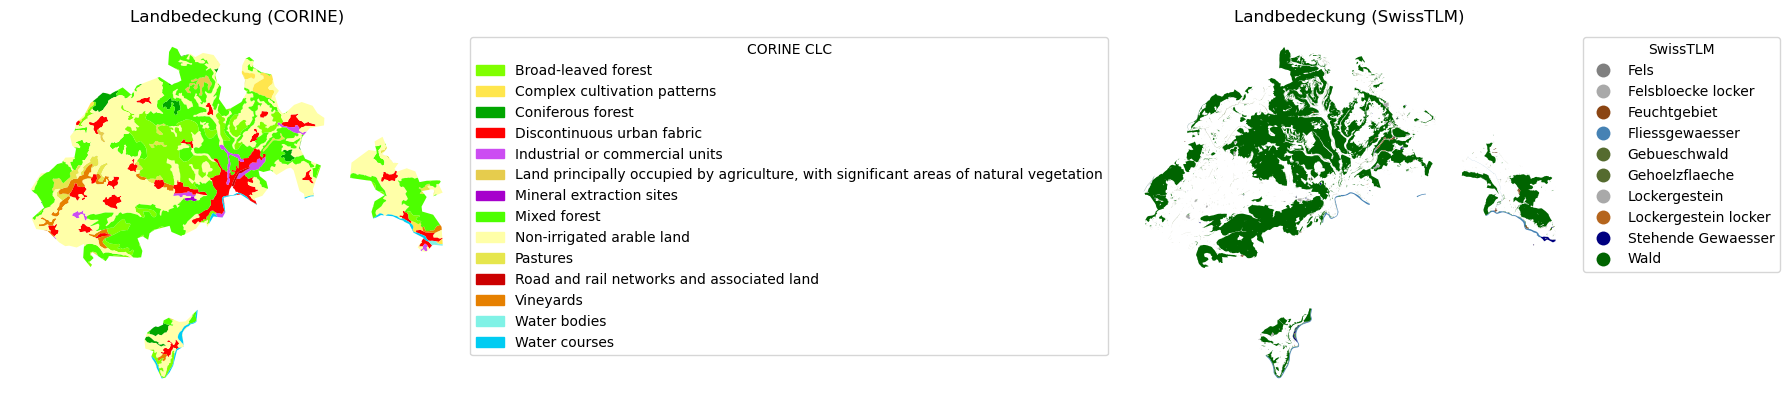

In [145]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, Normalize

# --- ANNAHME: Ihre Daten sind bereits geladen ---
# landcover_sh_clc = ... # Ihre CORINE GeoDataFrame
# landcover_sh = ...     # Ihre SwissTLM GeoDataFrame

# 1. Korrigieren Sie die Datentypen und konvertieren Sie RGB zu Hex für CLC
def rgb_to_hex(rgb_string):
    if pd.isna(rgb_string): return '#000000'
    r, g, b = map(int, rgb_string.split('-'))
    return f'#{r:02x}{g:02x}{b:02x}'

# Annahme: 'RGB' und 'LABEL3' sind bereits in landcover_sh_clc vorhanden
landcover_sh_clc['HEX_COLOR'] = landcover_sh_clc['RGB'].apply(rgb_to_hex)

# 2. Definieren Sie die Farbkarte für die SwissTLM-Karte
landscape_colors = {
    "Fels": "#808080", "Fels locker": "#a9a9a9", "Felsbloecke": "#808080",
    "Felsbloecke locker": "#a9a9a9", "Lockergestein": "#a9a9a9",
    "Lockergestein locker": "#b5651d", "Fliessgewaesser": "#4682b4",
    "Stehende Gewaesser": "#000080", "Gletscher": "#b0e0e6",
    "Schneefeld Toteis": "#add8e6", "Wald": "#006400", "Wald offen": "#32cd32",
    "Gehoelzflaeche": "#556b2f", "Gebueschwald": "#556b2f", "Feuchtgebiet": "#8b4513"
}
unique_landscapes = sorted(landcover_sh["objektart"].unique())
colors_for_cmap = [landscape_colors.get(name, '#FFFFFF') for name in unique_landscapes]
swisstlm_cmap = ListedColormap(colors_for_cmap)


# --- 3. Die kombinierte Karte erstellen ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10)) # Eine Figur mit 2 Subplots


# --- CORINE Land Cover Plot (im ersten Subplot, ax1) ---
landcover_sh_clc.plot(
    ax=ax1,
    color=landcover_sh_clc['HEX_COLOR']
)

# Legende für den CORINE-Plot erstellen
legend_data_clc = landcover_sh_clc[['landcover', 'HEX_COLOR']].drop_duplicates().sort_values('landcover')
legend_handles_clc = [mpatches.Patch(color=row['HEX_COLOR'], label=row['landcover'])
                      for index, row in legend_data_clc.iterrows()]
ax1.legend(handles=legend_handles_clc, title="CORINE CLC", loc='upper left', bbox_to_anchor=(1, 1))

ax1.set_title("Landbedeckung (CORINE)")
ax1.set_axis_off()


# --- SwissTLM Plot (im zweiten Subplot, ax2) ---
landcover_sh.plot(
    column="objektart",
    ax=ax2,
    cmap=swisstlm_cmap,
    legend=True,
    legend_kwds={'title': 'SwissTLM', 'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)

ax2.set_title("Landbedeckung (SwissTLM)")
ax2.set_axis_off()


plt.tight_layout(rect=[0, 0, 0.9, 1]) # Anpassung des Layouts
plt.show()

SwissTLM categories translated to English.
CRS matched for a successful overlay.


c:\Users\Lukas\anaconda3\envs\pa2\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 119 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


CORINE data to fill in gaps has been isolated.
Final combined GeoDataFrame created.
      final_label                                           geometry
0     Wooded Area  POLYGON Z ((2706081.343 1278871.675 419.373, 2...
1     Wooded Area  POLYGON Z ((2706081.899 1278903.539 419.989, 2...
2  Standing Water  POLYGON Z ((2706067.95 1278906.85 419.037, 270...
3  Standing Water  POLYGON Z ((2706005.056 1278943.244 419.176, 2...
4         Wetland  POLYGON Z ((2706073.528 1278894.996 419.176, 2...


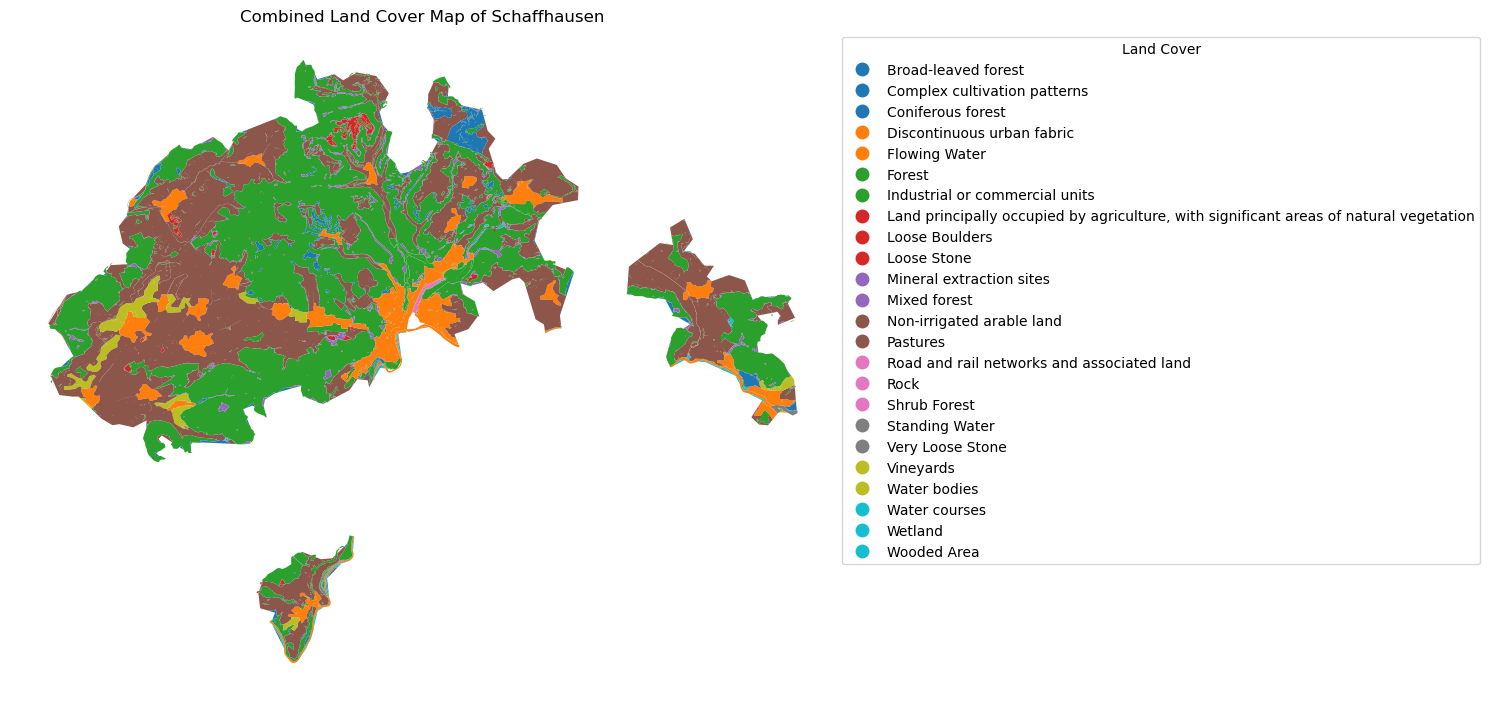

In [146]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# --- Step 1: Translate SwissTLM categories to English ---
translation_dict = {
    "Fels": "Rock", "Fels locker": "Loose Rock", "Felsbloecke": "Boulders",
    "Felsbloecke locker": "Loose Boulders", "Lockergestein": "Loose Stone",
    "Lockergestein locker": "Very Loose Stone", "Fliessgewaesser": "Flowing Water",
    "Stehende Gewaesser": "Standing Water", "Gletscher": "Glacier",
    "Schneefeld Toteis": "Snowfield/Dead Ice", "Wald": "Forest",
    "Wald offen": "Open Forest", "Gehoelzflaeche": "Wooded Area",
    "Gebueschwald": "Shrub Forest", "Feuchtgebiet": "Wetland"
}

landcover_sh['objektart_en'] = landcover_sh['objektart'].map(translation_dict)
print("SwissTLM categories translated to English.")


# --- Step 2: Ensure CRS consistency for the spatial join ---
if landcover_sh.crs != landcover_sh_clc.crs:
    landcover_sh_clc = landcover_sh_clc.to_crs(landcover_sh.crs)
    print("CRS matched for a successful overlay.")


# --- Step 3: Find CORINE polygons that do not overlap with SwissTLM ---
# This is the key operation for filling in the gaps.
corine_gaps = gpd.overlay(landcover_sh_clc, landcover_sh, how='difference')
print("CORINE data to fill in gaps has been isolated.")


# --- Step 4: Unify the datasets with a single name column ---
# Prepare the SwissTLM data for combination
combined_swisstlm = landcover_sh.copy()
combined_swisstlm['final_label'] = combined_swisstlm['objektart_en']

# Prepare the CORINE data for combination
combined_corine_gaps = corine_gaps.copy()
combined_corine_gaps['final_label'] = combined_corine_gaps['landcover']

# Combine the two datasets
final_map_data = gpd.GeoDataFrame(pd.concat([combined_swisstlm, combined_corine_gaps],
                                            ignore_index=True), crs=landcover_sh.crs)

print("Final combined GeoDataFrame created.")
print(final_map_data[['final_label', 'geometry']].head())


# --- Step 5: Visualize the Combined Map ---
# Create a unified color dictionary for the combined labels
unique_labels = final_map_data['final_label'].unique()
unified_colors = {}
for label in unique_labels:
    # Get color from the SwissTLM dict if it's there
    if label in translation_dict.values():
        german_label = next((k for k, v in translation_dict.items() if v == label), None)
        unified_colors[label] = landscape_colors[german_label]
    # Otherwise, get color from the CLC legend (using the original DataFrame)
    else:
        # Find the matching LABEL3 in the CLC legend and get its color
        rgb_string = clc_legend[clc_legend['LABEL3'] == label]['RGB'].iloc[0]
        # You'll need the rgb_to_hex function from our last conversation
        def rgb_to_hex(rgb_string):
            r, g, b = map(int, rgb_string.split('-'))
            return f'#{r:02x}{g:02x}{b:02x}'
        unified_colors[label] = rgb_to_hex(rgb_string)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the combined map using the 'final_label' for coloring
final_map_data.plot(
    column='final_label',
    ax=ax,
    legend=True,
    legend_kwds={'title': 'Land Cover', 'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)

ax.set_title("Combined Land Cover Map of Schaffhausen")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [148]:
# Mapping from detailed labels to broader category names
category_mapping = {
    # Forest Categories
    'Forest': 'Forest', 'Open Forest': 'Forest', 'Wooded Area': 'Forest', 
    'Shrub Forest': 'Forest', 'Coniferous forest': 'Forest',
    'Broad-leaved forest': 'Forest', 'Mixed forest': 'Forest',

    # Agriculture Categories
    'Complex cultivation patterns': 'Agriculture', 'Non-irrigated arable land': 'Agriculture', 
    'Pastures': 'Agriculture', 'Vineyards': 'Agriculture',
    'Land principally occupied by agriculture with significant areas of natural vegetation': 'Agriculture',

    # Water Categories
    'Flowing Water': 'Water', 'Standing Water': 'Water',
    'Water courses': 'Water', 'Water bodies': 'Water',

    # Urban Categories
    'Continuous urban fabric': 'Urban', 'Discontinuous urban fabric': 'Urban', 
    'Industrial or commercial units': 'Urban', 'Road and rail networks and associated land': 'Urban', 
    'Port areas': 'Urban', 'Airports': 'Urban',

    # Barren/Rock/Glacier Categories
    'Rock': 'Barren', 'Loose Rock': 'Barren', 'Boulders': 'Barren', 'Loose Boulders': 'Barren', 
    'Loose Stone': 'Barren', 'Very Loose Stone': 'Barren',
    'Mineral extraction sites': 'Barren', 'Construction sites': 'Barren',
    'Dump sites': 'Barren', 'Bare rocks': 'Barren',
    'Beaches, dunes, sand flats': 'Barren', 'Sparsely vegetated areas': 'Barren',
    'Burnt areas': 'Barren', 'Land without current use': 'Barren',

    # Other
    'Wetland': 'Wetland', 'Wetlands': 'Wetland',
    'Glacier': 'Glacier', 'Snowfield/Dead Ice': 'Glacier',
    'Glaciers and perpetual snow': 'Glacier'
}

# Assign a unique integer ID to each broader category
category_to_id = {
    'Forest': 1,
    'Agriculture': 2,
    'Water': 3,
    'Urban': 4,
    'Barren': 5,
    'Wetland': 6,
    'Glacier': 7
}

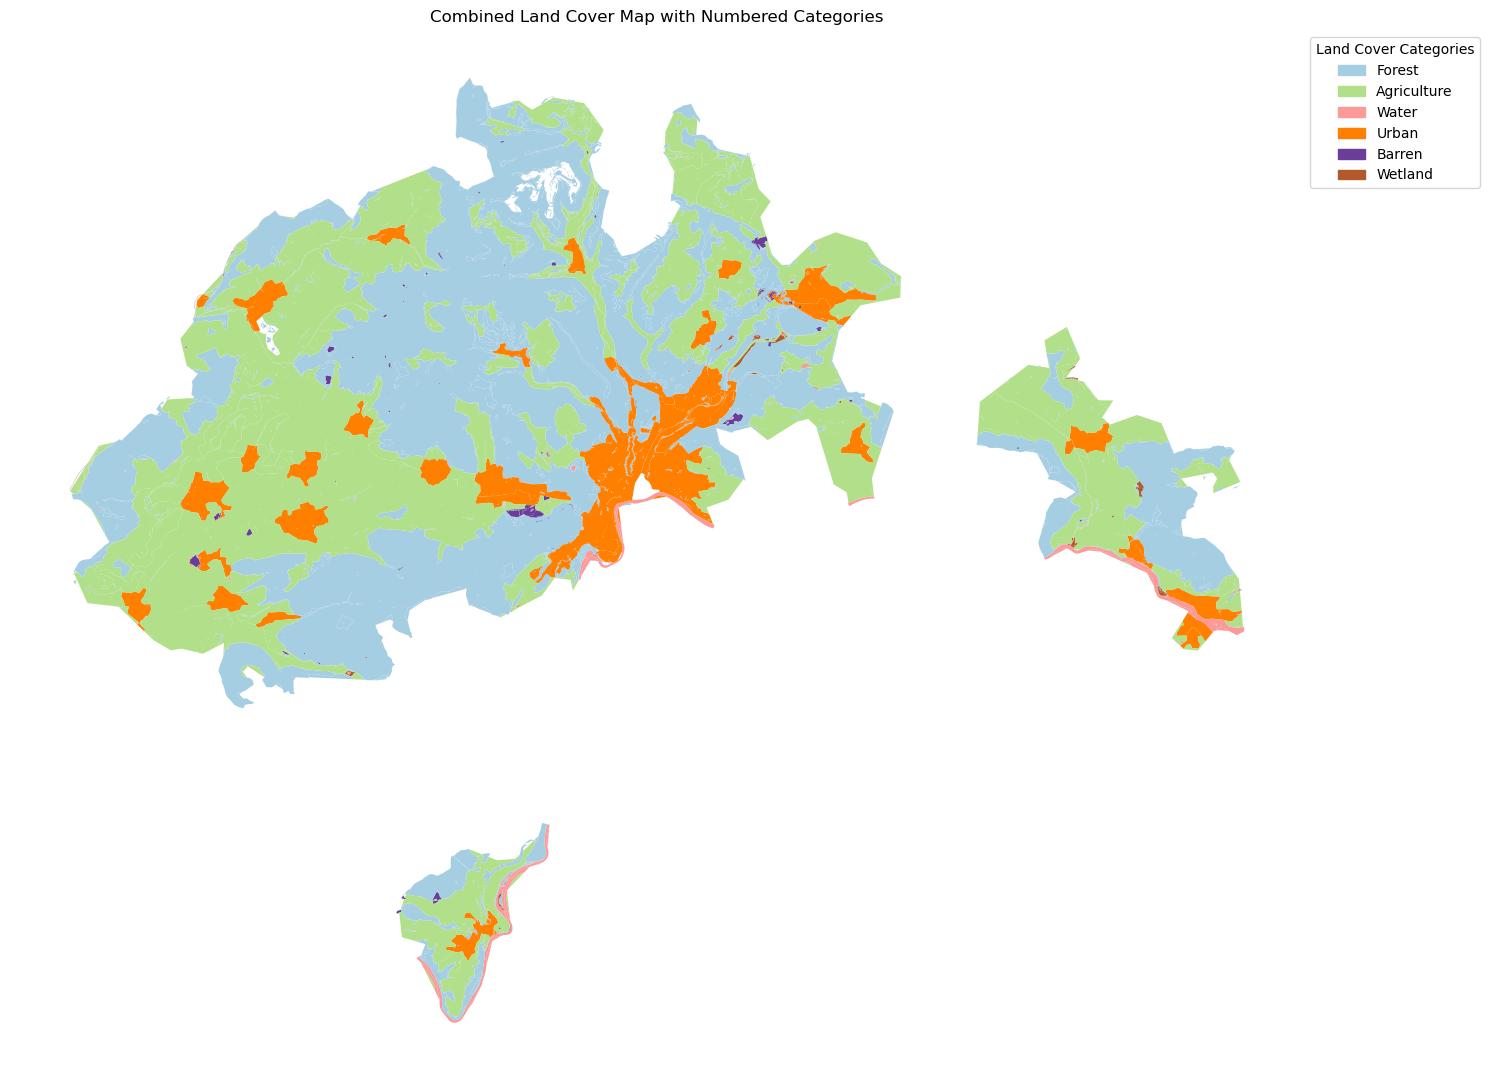

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colormaps


# Apply the new category mapping to create a new column with category names
final_map_data['broader_category'] = final_map_data['final_label'].map(category_mapping)

# Apply the category-to-ID mapping to get a new column with unique numbers
final_map_data['broader_category_id'] = final_map_data['broader_category'].map(category_to_id)


# --- Create the plot with numbered categories ---
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Get the list of unique IDs and their corresponding names for the legend
unique_ids = sorted(final_map_data['broader_category_id'].dropna().unique())
id_to_name = {v: k for k, v in category_to_id.items()}
legend_labels = [id_to_name[id_val] for id_val in unique_ids]

# Define a color palette for the IDs
colors = plt.get_cmap('Paired', len(unique_ids)).colors

# Create a custom colormap and normalization
cmap = ListedColormap(colors)
norm = BoundaryNorm(unique_ids + [unique_ids[-1] + 1], cmap.N)

# Plot the map using the new ID column
final_map_data.plot(
    column='broader_category_id',
    ax=ax,
    cmap=cmap,
    norm=norm
)

# Create and add a custom legend
patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(len(unique_ids))]
ax.legend(handles=patches, title="Land Cover Categories", loc='upper left', bbox_to_anchor=(1, 1))

ax.set_title("Combined Land Cover Map with Numbered Categories")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# # 5. Optional speichern
# landcover_sh.to_file("landcover_schaffhausen.gpkg", driver="GPKG")

In [150]:
print(final_map_data.columns)

Index(['uuid', 'datum_aenderung', 'datum_erstellung', 'erstellung_jahr',
       'erstellung_monat', 'grund_aenderung', 'herkunft', 'herkunft_jahr',
       'herkunft_monat', 'objektart', 'revision_jahr', 'revision_monat',
       'revision_qualitaet', 'geometry', 'objektart_en', 'final_label',
       'OBJECTID', 'Code_18', 'Remark', 'Area_Ha', 'Shape_Length',
       'Shape_Area', 'landcover', 'RGB', 'HEX_COLOR', 'broader_category',
       'broader_category_id'],
      dtype='object')


Define Cost Rules

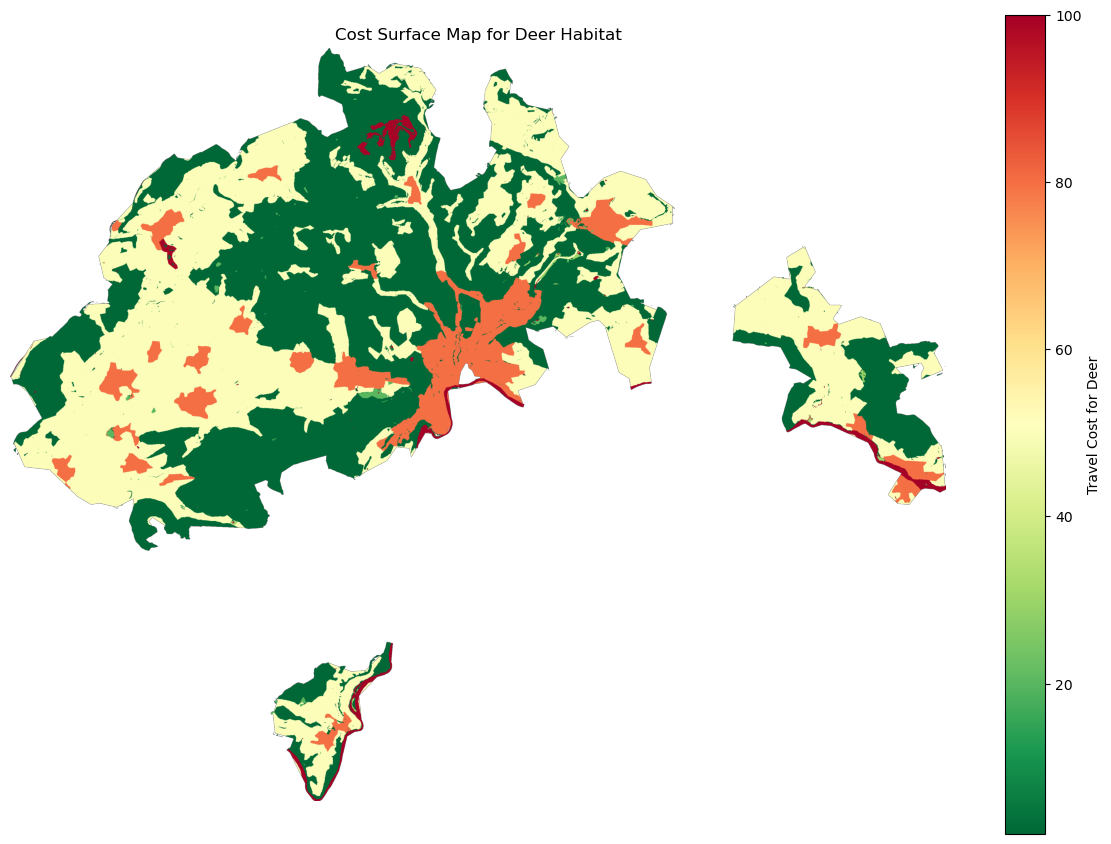

In [161]:
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio import Affine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- ASSUMPTION: 'final_map_data' is created and has 'final_label' column ---
# and the category_mapping and category_to_id dictionaries are defined.

# Add a new category for any missing values
category_to_id['Unclassified'] = 8

# Create a mapping from detailed labels to broader category IDs, handling any missing values
final_map_data['broader_category_id'] = final_map_data['final_label'].map(category_mapping).map(category_to_id)

# 1. Fill any remaining NaN values in the ID column
# This replaces all NaN values with the new 'Unclassified' ID (8)
final_map_data['broader_category_id'] = final_map_data['broader_category_id'].fillna(8)

# Now, all values are valid integers, and no NaNs exist to cause a KeyError.

# 2. Define the cost rules, now including the 'Unclassified' category
cost_rules = {
    1: 2,   # Forest
    2: 50,   # Agriculture
    3: 100, # Water
    4: 80,  # Urban
    5: 20,  # Barren
    6: 30,  # Wetland
    7: 100, # Glacier
    8: 99   # Unclassified: high cost as we don't know what it is
}

# --- Continue with the Rasterization steps as before ---
geometries = [
    (geom, cost_rules[cat_id]) for geom, cat_id in zip(
        final_map_data.geometry, final_map_data['broader_category_id']
    )
]

# Define the raster properties
xmin, ymin, xmax, ymax = final_map_data.total_bounds
resolution = 10
width = int((xmax - xmin) / resolution)
height = int((ymax - ymin) / resolution)
transform = Affine(resolution, 0, xmin, 0, -resolution, ymax)

# Rasterize the data
cost_surface = rasterize(
    geometries,
    out_shape=(height, width),
    transform=transform,
    all_touched=True,
    dtype=np.float32,
    fill=np.nan
)

# Visualize the cost surface
fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(
    cost_surface,
    cmap='RdYlGn_r',
    extent=[xmin, xmax, ymin, ymax]
)
cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('Travel Cost for Deer')
ax.set_title("Cost Surface Map for Deer Habitat")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_axis_off()
plt.tight_layout()
plt.show()